# 🔍 Análise de Erro Detalhada

Análise profunda dos erros do modelo para identificar padrões e oportunidades de melhoria.

## 📋 Conteúdo

1. **Erro por Região** - Quais regiões têm maior erro?
2. **Erro por Hora do Dia** - Horários problemáticos
3. **Erro por Estação/Mês** - Padrões sazonais de erro
4. **Calibration Analysis** - Previsões vs valores reais
5. **Análise de Resíduos** - Normalidade, heterocedasticidade
6. **Identificação de Outliers** - Quando o modelo falha completamente
7. **Erro vs Features** - Quais features causam mais erro?

## 1. Setup

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib
import warnings
from datetime import datetime
from scipy import stats

from src.features.feature_engineering import FeatureEngineer
from src.models.evaluation import ModelEvaluator

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)

print('✓ Bibliotecas carregadas')

✓ Bibliotecas carregadas


## 2. Carregar Dados e Modelo

In [2]:
# Carregar dados
df = pd.read_parquet('../data/processed/processed_data.parquet')

# Feature engineering
fe = FeatureEngineer()
df_features = fe.create_all_features(df)

print(f"Dados carregados: {len(df_features):,} linhas")
print(f"Features: {df_features.shape[1]} colunas")

Creating features...
  - Temporal features
  - Lag features
  - Rolling features
  - Interaction features
  - Removed 240 rows with NaN
Dados carregados: 174,965 linhas
Features: 73 colunas


In [3]:
# Carregar melhor modelo
model_path = Path('../data/models/xgboost_best.pkl')

if model_path.exists():
    model = joblib.load(model_path)
    print(f"✓ Modelo carregado: {model_path.name}")
else:
    print("⚠️  Modelo não encontrado. Execute primeiro notebook 04_model_training.ipynb")
    raise FileNotFoundError(model_path)

✓ Modelo carregado: xgboost_best.pkl


## 3. Preparar Dados de Teste

In [4]:
# Preparar features
exclude_cols = ['timestamp', 'consumption_mw', 'region', 'holiday_name']
for col in df_features.columns:
    if col in exclude_cols:
        continue
    if pd.api.types.is_datetime64_any_dtype(df_features[col]) or df_features[col].dtype == 'object':
        exclude_cols.append(col)

features = [c for c in df_features.columns if c not in exclude_cols]

# Split temporal - usar apenas conjunto de teste (últimos 15%)
df_sorted = df_features.sort_values('timestamp').reset_index(drop=True)
test_start = int(0.85 * len(df_sorted))
df_test = df_sorted.iloc[test_start:].copy()

X_test = df_test[features].values
y_test = df_test['consumption_mw'].values

print(f"Conjunto de teste: {len(X_test):,} amostras")
print(f"Período: {df_test['timestamp'].min()} → {df_test['timestamp'].max()}")

Conjunto de teste: 26,245 amostras
Período: 2024-05-26 08:00:00 → 2024-12-31 00:00:00


## 4. Gerar Previsões e Calcular Erros

In [5]:
# Fazer previsões
y_pred = model.predict(X_test)

# Calcular erros
df_test['y_true'] = y_test
df_test['y_pred'] = y_pred
df_test['error'] = y_test - y_pred
df_test['abs_error'] = np.abs(df_test['error'])
df_test['pct_error'] = (df_test['error'] / y_test) * 100
df_test['abs_pct_error'] = np.abs(df_test['pct_error'])

# Adicionar features temporais para análise
df_test['hour'] = df_test['timestamp'].dt.hour
df_test['day_of_week'] = df_test['timestamp'].dt.dayofweek
df_test['month'] = df_test['timestamp'].dt.month
df_test['season'] = df_test['month'].apply(lambda m: 
    'Inverno' if m in [12,1,2] else
    'Primavera' if m in [3,4,5] else
    'Verão' if m in [6,7,8] else 'Outono'
)

# Métricas globais
evaluator = ModelEvaluator()
metrics = evaluator.calculate_metrics(y_test, y_pred, prefix='test_')

print('\n' + '='*80)
print('MÉTRICAS GLOBAIS DE ERRO')
print('='*80)
print(f"MAE:   {metrics['test_mae']:.2f} MW")
print(f"RMSE:  {metrics['test_rmse']:.2f} MW")
print(f"MAPE:  {metrics['test_mape']:.2f}%")
print(f"R²:    {metrics['test_r2']:.4f}")
print(f"\nErro médio: {df_test['error'].mean():.2f} MW")
print(f"Erro mediano: {df_test['error'].median():.2f} MW")
print(f"Desvio do erro: {df_test['error'].std():.2f} MW")
print('='*80)


MÉTRICAS GLOBAIS DE ERRO
MAE:   10.65 MW
RMSE:  20.25 MW
MAPE:  0.86%
R²:    0.9995

Erro médio: 0.53 MW
Erro mediano: 0.40 MW
Desvio do erro: 20.24 MW


## 5. Análise de Erro por Região

In [6]:
# Estatísticas por região
error_by_region = df_test.groupby('region').agg({
    'error': ['mean', 'std', 'min', 'max'],
    'abs_error': ['mean', 'median'],
    'abs_pct_error': ['mean', 'median'],
    'y_true': 'count'
}).round(2)

error_by_region.columns = ['_'.join(col).strip() for col in error_by_region.columns.values]
error_by_region = error_by_region.sort_values('abs_pct_error_mean', ascending=False)

print('\n' + '='*80)
print('ERRO POR REGIÃO')
print('='*80)
print(error_by_region)
print('='*80)


ERRO POR REGIÃO
          error_mean  error_std  error_min  error_max  abs_error_mean  \
region                                                                  
Algarve         0.19       6.90     -52.59      59.88            4.43   
Alentejo        0.41       8.17     -57.02      67.86            5.33   
Lisboa          1.66      35.32    -280.16     298.25           21.42   
Centro          0.11      14.76    -179.43     140.52            9.16   
Norte           0.26      21.62    -187.26     201.38           12.90   

          abs_error_median  abs_pct_error_mean  abs_pct_error_median  \
region                                                                 
Algarve               2.63                0.96                  0.52   
Alentejo              3.36                0.91                  0.53   
Lisboa               11.17                0.84                  0.43   
Centro                5.04                0.81                  0.41   
Norte                 6.68             

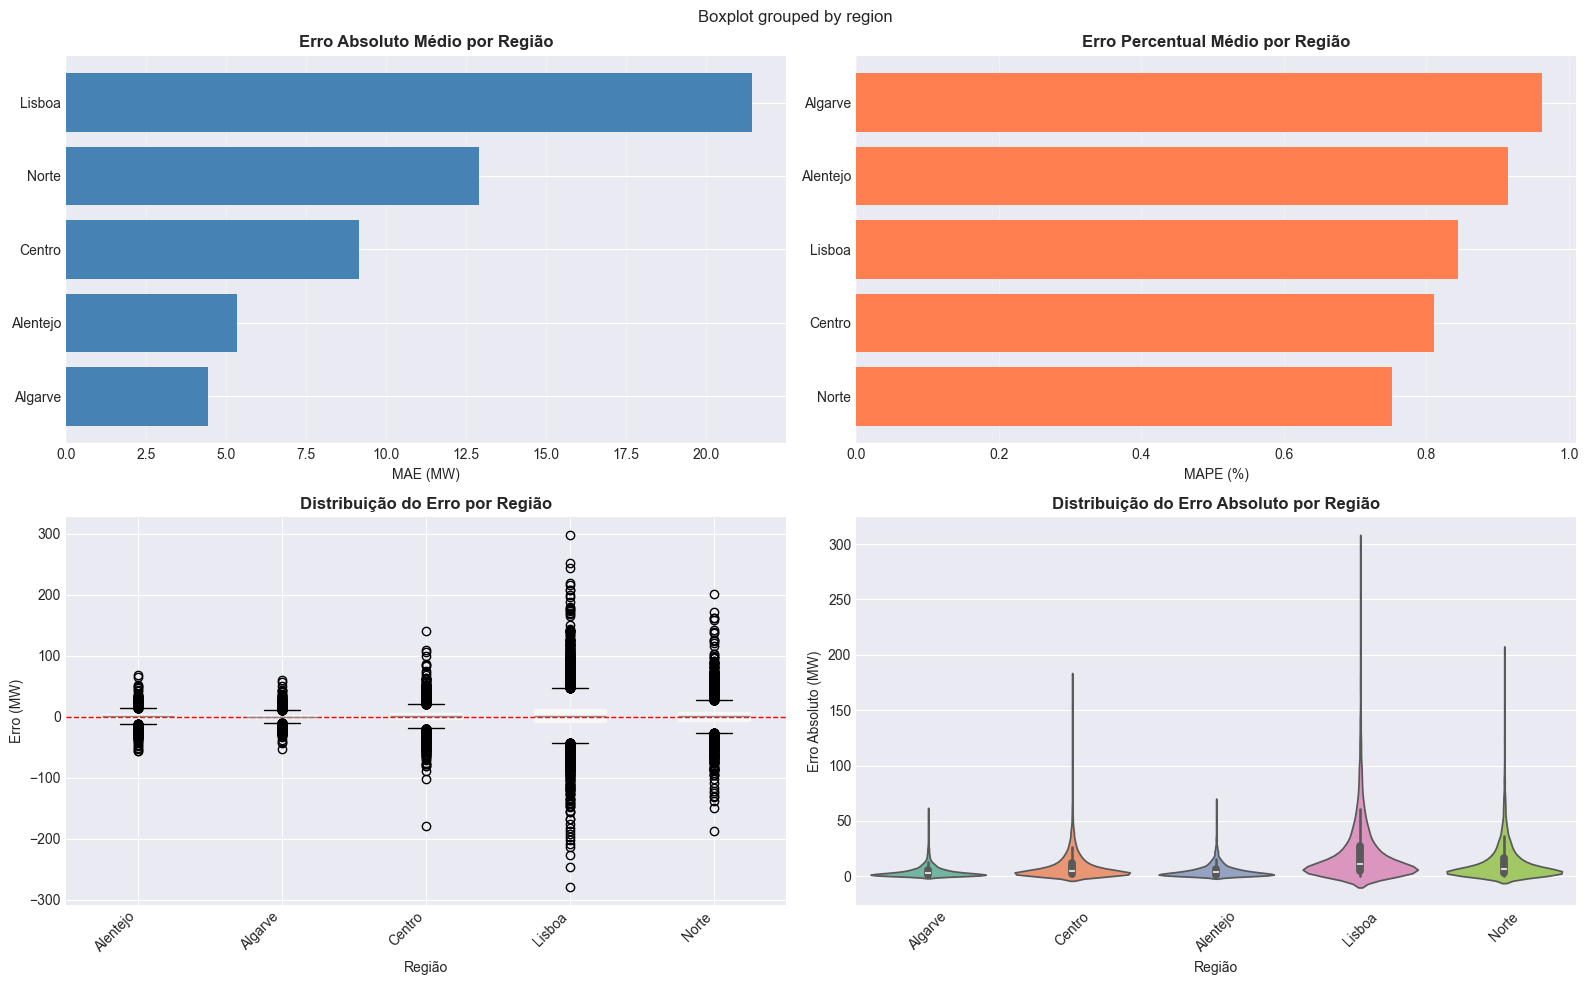

✓ Gráfico salvo: data/models/error_by_region.png


In [7]:
# Visualização
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. MAE por região
mae_by_region = df_test.groupby('region')['abs_error'].mean().sort_values()
axes[0, 0].barh(mae_by_region.index, mae_by_region.values, color='steelblue')
axes[0, 0].set_xlabel('MAE (MW)')
axes[0, 0].set_title('Erro Absoluto Médio por Região', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='x')

# 2. MAPE por região
mape_by_region = df_test.groupby('region')['abs_pct_error'].mean().sort_values()
axes[0, 1].barh(mape_by_region.index, mape_by_region.values, color='coral')
axes[0, 1].set_xlabel('MAPE (%)')
axes[0, 1].set_title('Erro Percentual Médio por Região', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='x')

# 3. Box plot de erro por região
df_test.boxplot(column='error', by='region', ax=axes[1, 0], patch_artist=True)
axes[1, 0].set_title('Distribuição do Erro por Região', fontweight='bold')
axes[1, 0].set_xlabel('Região')
axes[1, 0].set_ylabel('Erro (MW)')
axes[1, 0].axhline(0, color='red', linestyle='--', linewidth=1)
plt.sca(axes[1, 0])
plt.xticks(rotation=45, ha='right')

# 4. Violin plot de erro absoluto
sns.violinplot(data=df_test, x='region', y='abs_error', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Distribuição do Erro Absoluto por Região', fontweight='bold')
axes[1, 1].set_xlabel('Região')
axes[1, 1].set_ylabel('Erro Absoluto (MW)')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../data/models/error_by_region.png', dpi=300, bbox_inches='tight')
plt.show()

print('✓ Gráfico salvo: data/models/error_by_region.png')

## 6. Análise de Erro por Hora do Dia

In [8]:
# Estatísticas por hora
error_by_hour = df_test.groupby('hour').agg({
    'abs_error': ['mean', 'std'],
    'abs_pct_error': ['mean', 'std'],
    'error': ['mean'],
    'y_true': 'count'
}).round(2)

print('\nErro por Hora do Dia (Top 5 piores horas):')
worst_hours = error_by_hour.sort_values(('abs_pct_error', 'mean'), ascending=False)
print(worst_hours.head())


Erro por Hora do Dia (Top 5 piores horas):
     abs_error        abs_pct_error       error y_true
          mean    std          mean   std  mean  count
hour                                                  
23       18.67  21.71          2.19  2.07  2.89   1095
0        13.96  17.04          1.67  1.88 -0.41   1095
22       12.01  18.15          1.43  1.79  0.46   1095
1        13.03  20.98          1.41  2.01  0.57   1090
15       20.85  28.10          1.14  1.06  4.09   1095


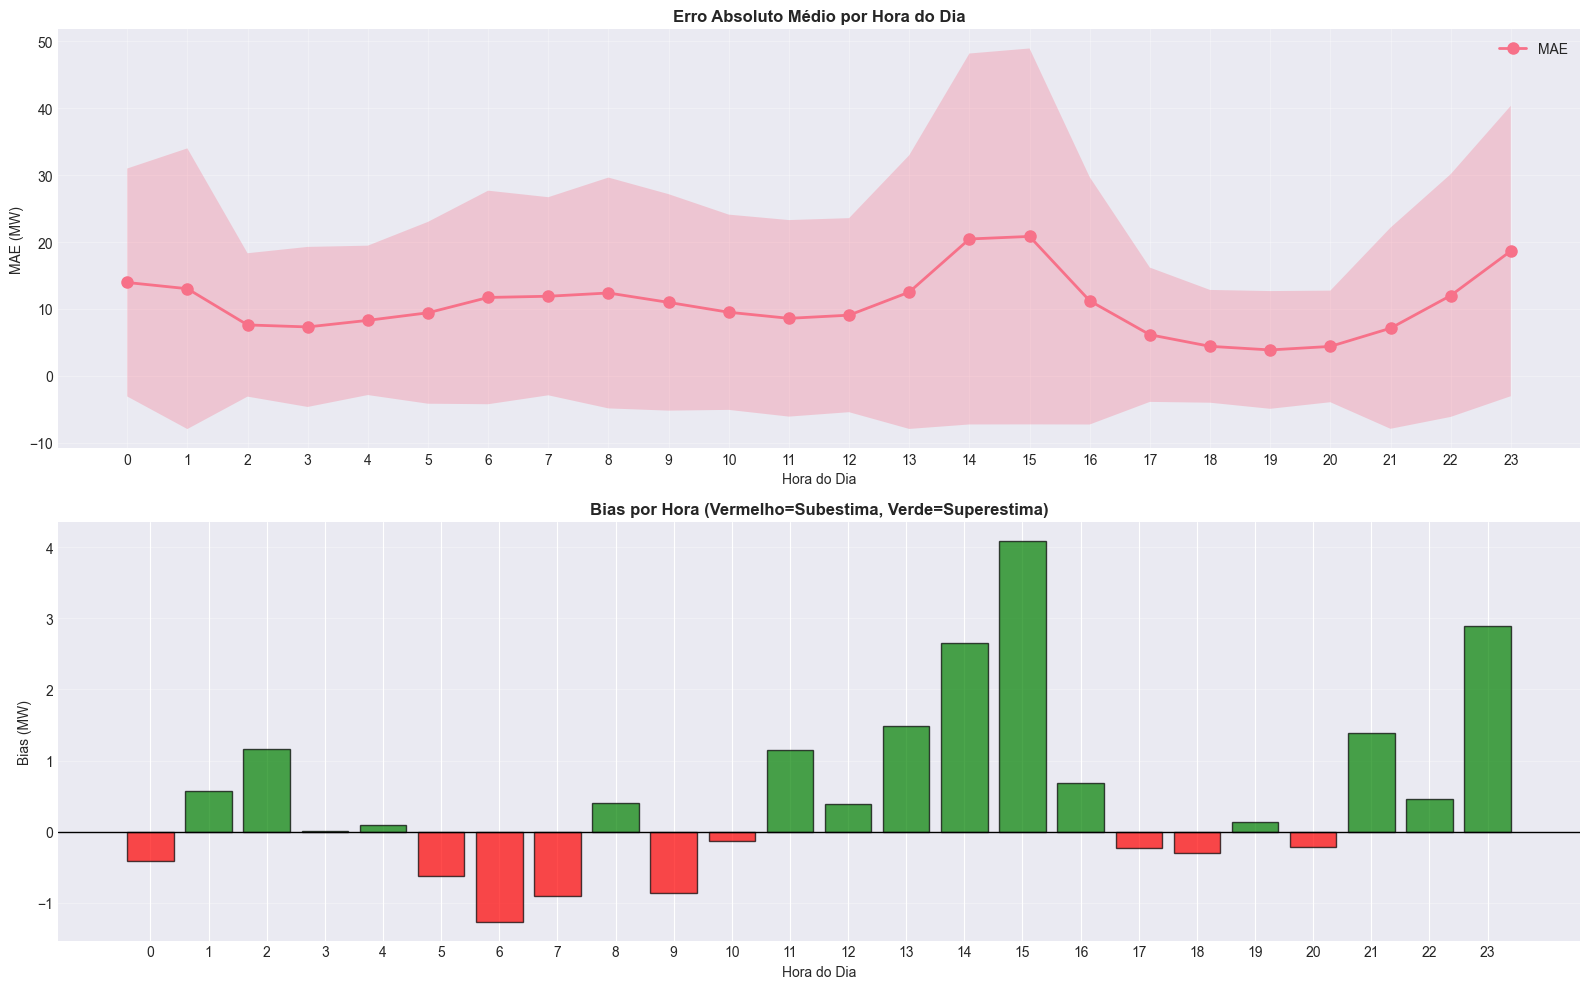

✓ Gráfico salvo: data/models/error_by_hour.png


In [9]:
# Visualização
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# 1. MAE por hora
hourly_mae = df_test.groupby('hour')['abs_error'].agg(['mean', 'std'])
axes[0].plot(hourly_mae.index, hourly_mae['mean'], marker='o', linewidth=2, markersize=8, label='MAE')
axes[0].fill_between(hourly_mae.index, 
                      hourly_mae['mean'] - hourly_mae['std'],
                      hourly_mae['mean'] + hourly_mae['std'],
                      alpha=0.3)
axes[0].set_xlabel('Hora do Dia')
axes[0].set_ylabel('MAE (MW)')
axes[0].set_title('Erro Absoluto Médio por Hora do Dia', fontweight='bold', fontsize=12)
axes[0].set_xticks(range(0, 24))
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# 2. Bias (erro médio) por hora
hourly_bias = df_test.groupby('hour')['error'].mean()
colors = ['red' if x < 0 else 'green' for x in hourly_bias.values]
axes[1].bar(hourly_bias.index, hourly_bias.values, color=colors, alpha=0.7, edgecolor='black')
axes[1].axhline(0, color='black', linestyle='-', linewidth=1)
axes[1].set_xlabel('Hora do Dia')
axes[1].set_ylabel('Bias (MW)')
axes[1].set_title('Bias por Hora (Vermelho=Subestima, Verde=Superestima)', fontweight='bold', fontsize=12)
axes[1].set_xticks(range(0, 24))
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../data/models/error_by_hour.png', dpi=300, bbox_inches='tight')
plt.show()

print('✓ Gráfico salvo: data/models/error_by_hour.png')

## 7. Análise de Erro por Estação/Mês

In [10]:
# Por estação
error_by_season = df_test.groupby('season').agg({
    'abs_error': ['mean', 'std'],
    'abs_pct_error': ['mean', 'std']
}).round(2)

print('\nErro por Estação:')
print(error_by_season.sort_values(('abs_pct_error', 'mean'), ascending=False))

# Por mês
error_by_month = df_test.groupby('month')['abs_pct_error'].mean().sort_values(ascending=False)
print('\nErro por Mês (MAPE %):')
month_names = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']
for month, mape in error_by_month.items():
    print(f"  {month_names[month-1]}: {mape:.2f}%")


Erro por Estação:
          abs_error        abs_pct_error      
               mean    std          mean   std
season                                        
Inverno        9.93  15.48          0.91  1.41
Outono        10.26  16.14          0.85  1.20
Verão         11.33  18.93          0.85  1.16
Primavera      9.66  12.75          0.72  0.89

Erro por Mês (MAPE %):
  Dez: 0.91%
  Nov: 0.90%
  Jun: 0.88%
  Jul: 0.86%
  Out: 0.83%
  Ago: 0.83%
  Set: 0.83%
  Mai: 0.72%


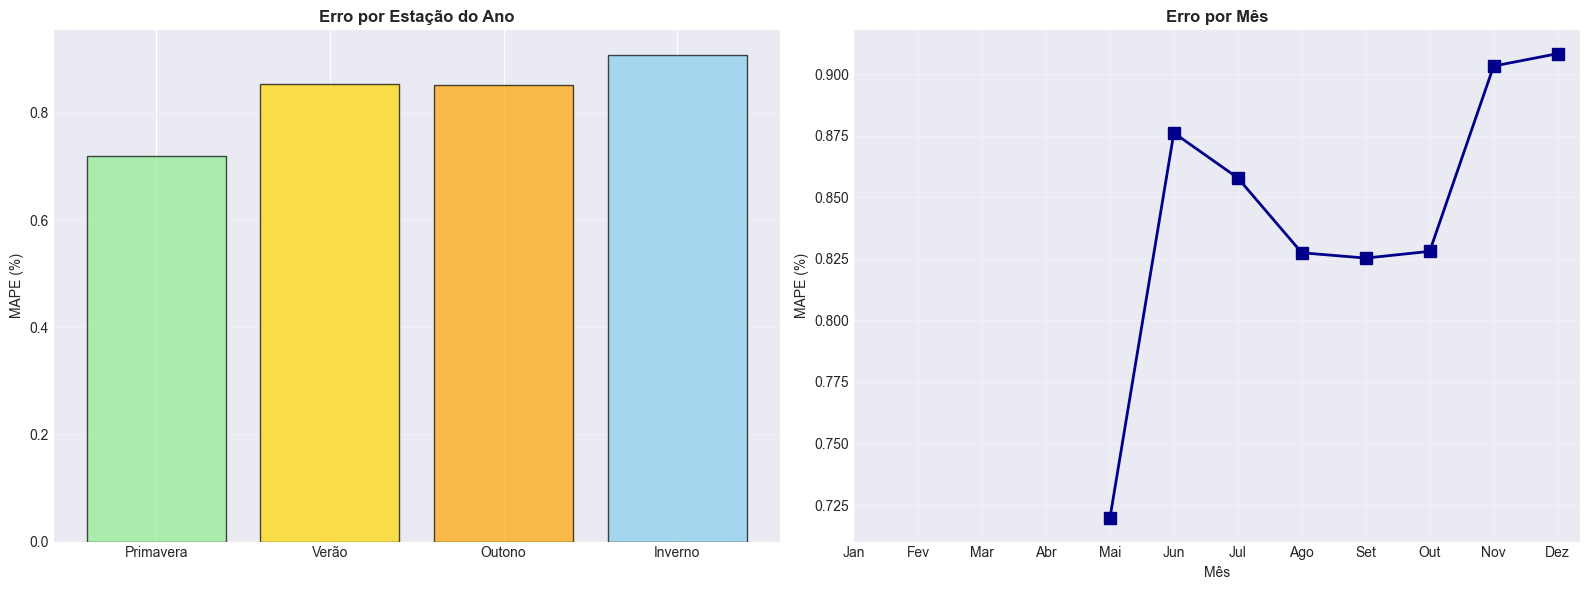

✓ Gráfico salvo: data/models/error_by_season.png


In [11]:
# Visualização
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Por estação
season_order = ['Primavera', 'Verão', 'Outono', 'Inverno']
season_mape = df_test.groupby('season')['abs_pct_error'].mean().reindex(season_order)
colors = ['#90EE90', '#FFD700', '#FFA500', '#87CEEB']
axes[0].bar(range(len(season_mape)), season_mape.values, color=colors, edgecolor='black', alpha=0.7)
axes[0].set_xticks(range(4))
axes[0].set_xticklabels(season_order)
axes[0].set_ylabel('MAPE (%)')
axes[0].set_title('Erro por Estação do Ano', fontweight='bold', fontsize=12)
axes[0].grid(True, alpha=0.3, axis='y')

# 2. Por mês
monthly_mape = df_test.groupby('month')['abs_pct_error'].mean()
axes[1].plot(monthly_mape.index, monthly_mape.values, marker='s', linewidth=2, markersize=8, color='darkblue')
axes[1].set_xlabel('Mês')
axes[1].set_ylabel('MAPE (%)')
axes[1].set_title('Erro por Mês', fontweight='bold', fontsize=12)
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_names)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/models/error_by_season.png', dpi=300, bbox_inches='tight')
plt.show()

print('✓ Gráfico salvo: data/models/error_by_season.png')

## 8. Calibration Analysis

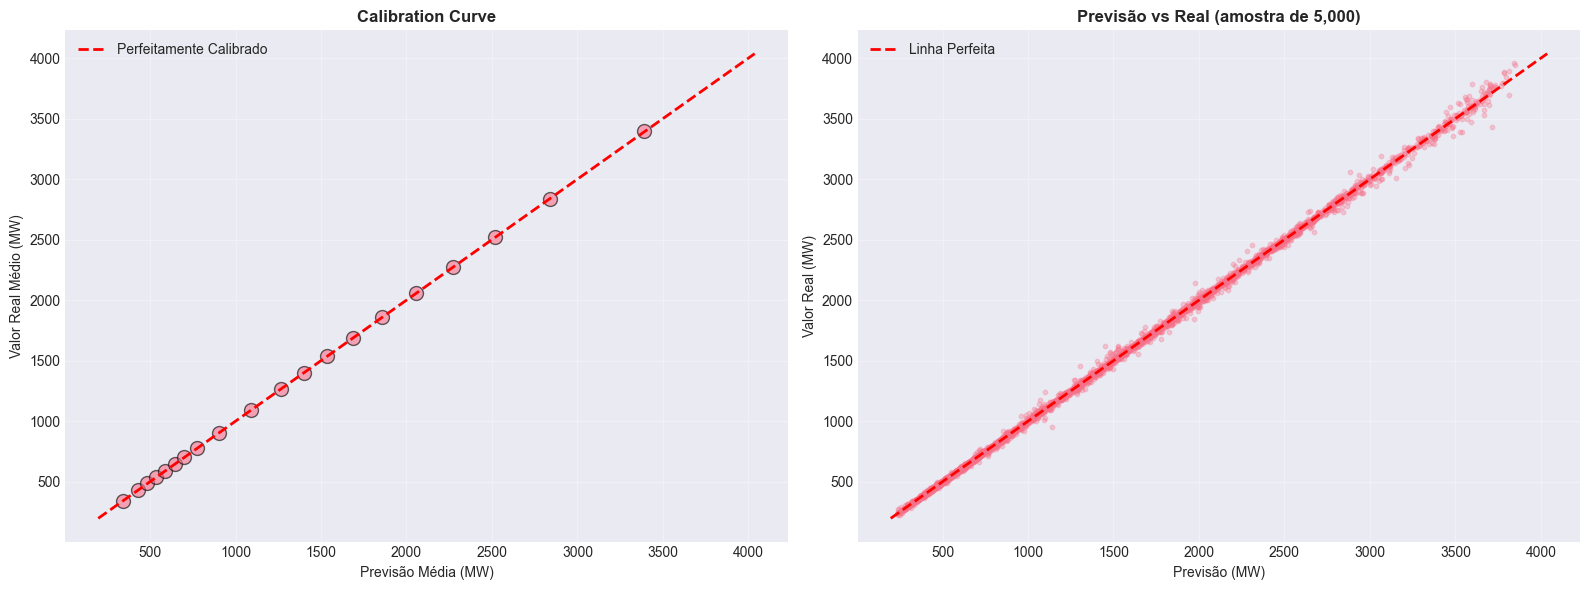

✓ Gráfico salvo: data/models/calibration_analysis.png


In [12]:
# Calibration plot: dividir em bins e comparar média prevista vs real
n_bins = 20
df_test_sorted = df_test.sort_values('y_pred')
df_test_sorted['bin'] = pd.qcut(df_test_sorted['y_pred'], q=n_bins, labels=False, duplicates='drop')

calibration_data = df_test_sorted.groupby('bin').agg({
    'y_pred': 'mean',
    'y_true': 'mean',
    'abs_error': 'mean'
})

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Calibration curve
axes[0].scatter(calibration_data['y_pred'], calibration_data['y_true'], s=100, alpha=0.6, edgecolors='black')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', linewidth=2, label='Perfeitamente Calibrado')
axes[0].set_xlabel('Previsão Média (MW)')
axes[0].set_ylabel('Valor Real Médio (MW)')
axes[0].set_title('Calibration Curve', fontweight='bold', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Scatter plot geral (amostra)
sample_size = min(5000, len(df_test))
df_sample = df_test.sample(sample_size, random_state=42)
axes[1].scatter(df_sample['y_pred'], df_sample['y_true'], alpha=0.3, s=10)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', linewidth=2, label='Linha Perfeita')
axes[1].set_xlabel('Previsão (MW)')
axes[1].set_ylabel('Valor Real (MW)')
axes[1].set_title(f'Previsão vs Real (amostra de {sample_size:,})', fontweight='bold', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/models/calibration_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print('✓ Gráfico salvo: data/models/calibration_analysis.png')

## 9. Análise de Resíduos

In [13]:
# Testes estatísticos
residuals = df_test['error'].values

print('\n' + '='*80)
print('ANÁLISE DE RESÍDUOS')
print('='*80)

# 1. Normalidade (Shapiro-Wilk em amostra)
sample_residuals = np.random.choice(residuals, size=min(5000, len(residuals)), replace=False)
shapiro_stat, shapiro_p = stats.shapiro(sample_residuals)
print(f"\n1. Teste de Normalidade (Shapiro-Wilk):")
print(f"   Statistic: {shapiro_stat:.6f}")
print(f"   P-value: {shapiro_p:.6f}")
print(f"   Conclusão: {'Normal' if shapiro_p > 0.05 else 'Não-Normal'} (α=0.05)")

# 2. Média dos resíduos (deve ser ~0)
print(f"\n2. Média dos Resíduos: {residuals.mean():.4f} MW")
print(f"   (Ideal: ~0, indica ausência de bias)")

# 3. Heterocedasticidade
print(f"\n3. Desvio Padrão dos Resíduos: {residuals.std():.2f} MW")

# 4. Assimetria e Curtose
skewness = stats.skew(residuals)
kurtosis = stats.kurtosis(residuals)
print(f"\n4. Assimetria: {skewness:.4f}")
print(f"   Curtose: {kurtosis:.4f}")

print('='*80)


ANÁLISE DE RESÍDUOS

1. Teste de Normalidade (Shapiro-Wilk):
   Statistic: 0.722767
   P-value: 0.000000
   Conclusão: Não-Normal (α=0.05)

2. Média dos Resíduos: 0.5266 MW
   (Ideal: ~0, indica ausência de bias)

3. Desvio Padrão dos Resíduos: 20.24 MW

4. Assimetria: 0.3568
   Curtose: 24.2458


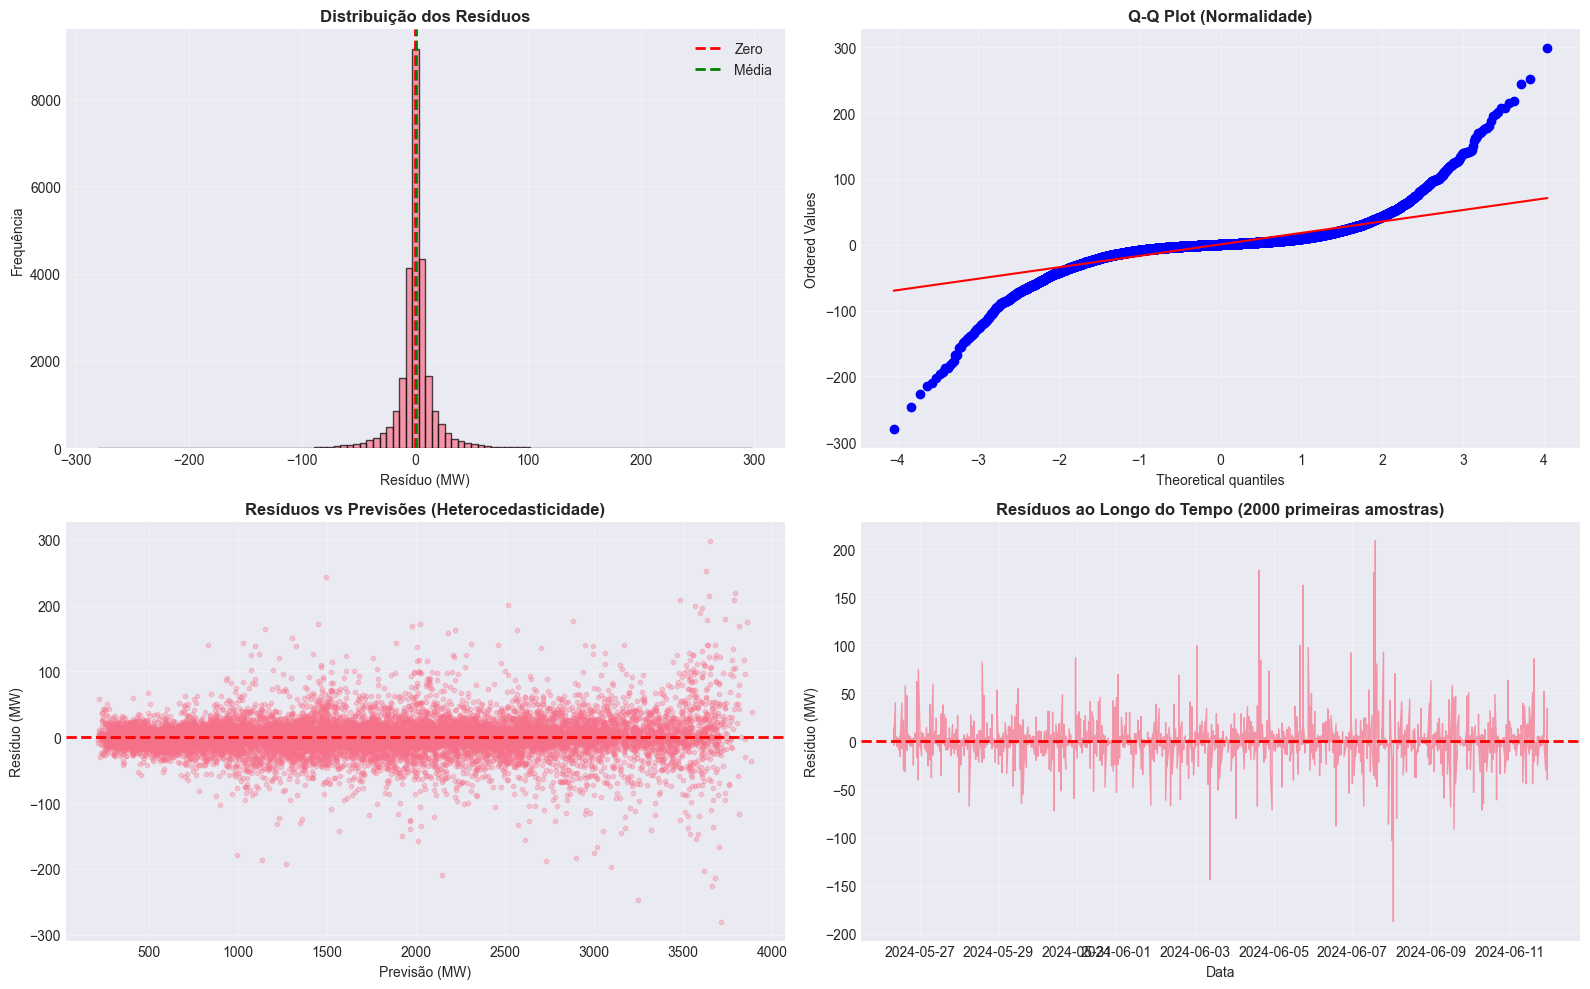

✓ Gráfico salvo: data/models/residuals_analysis.png


In [14]:
# Visualizações de resíduos
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Histograma de resíduos
axes[0, 0].hist(residuals, bins=100, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero')
axes[0, 0].axvline(residuals.mean(), color='green', linestyle='--', linewidth=2, label='Média')
axes[0, 0].set_xlabel('Resíduo (MW)')
axes[0, 0].set_ylabel('Frequência')
axes[0, 0].set_title('Distribuição dos Resíduos', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Q-Q Plot
stats.probplot(residuals, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot (Normalidade)', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Resíduos vs Previsões (heterocedasticidade)
axes[1, 0].scatter(df_test['y_pred'], df_test['error'], alpha=0.3, s=10)
axes[1, 0].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Previsão (MW)')
axes[1, 0].set_ylabel('Resíduo (MW)')
axes[1, 0].set_title('Resíduos vs Previsões (Heterocedasticidade)', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# 4. Resíduos ao longo do tempo (amostra)
df_temporal = df_test.sort_values('timestamp').iloc[:2000].copy()
axes[1, 1].plot(df_temporal['timestamp'], df_temporal['error'], linewidth=1, alpha=0.7)
axes[1, 1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Data')
axes[1, 1].set_ylabel('Resíduo (MW)')
axes[1, 1].set_title('Resíduos ao Longo do Tempo (2000 primeiras amostras)', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/models/residuals_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print('✓ Gráfico salvo: data/models/residuals_analysis.png')

## 10. Identificação de Outliers de Erro

In [15]:
# Encontrar casos com erro muito alto (top 1%)
error_threshold = df_test['abs_error'].quantile(0.99)
df_outliers = df_test[df_test['abs_error'] > error_threshold].copy()

print('\n' + '='*80)
print('OUTLIERS DE ERRO (Top 1%)')
print('='*80)
print(f"Threshold: {error_threshold:.2f} MW")
print(f"Quantidade: {len(df_outliers):,} amostras ({len(df_outliers)/len(df_test)*100:.2f}%)")
print(f"\nErro médio nos outliers: {df_outliers['abs_error'].mean():.2f} MW")
print(f"Erro máximo: {df_outliers['abs_error'].max():.2f} MW")

# Análise por região
print("\nOutliers por região:")
outlier_by_region = df_outliers['region'].value_counts()
for region, count in outlier_by_region.items():
    pct = count / len(df_outliers) * 100
    print(f"  {region}: {count} ({pct:.1f}%)")

# Análise por hora
print("\nOutliers por hora (top 5):")
outlier_by_hour = df_outliers['hour'].value_counts().head()
for hour, count in outlier_by_hour.items():
    print(f"  {hour}h: {count}")

print('='*80)


OUTLIERS DE ERRO (Top 1%)
Threshold: 84.88 MW
Quantidade: 263 amostras (1.00%)

Erro médio nos outliers: 121.23 MW
Erro máximo: 298.25 MW

Outliers por região:
  Lisboa: 206 (78.3%)
  Norte: 49 (18.6%)
  Centro: 8 (3.0%)

Outliers por hora (top 5):
  14h: 41
  15h: 39
  1h: 21
  23h: 20
  13h: 18


In [16]:
# Visualizar piores casos
worst_cases = df_test.nlargest(10, 'abs_error')[['timestamp', 'region', 'y_true', 'y_pred', 'error', 'abs_error']]

print('\n10 PIORES PREVISÕES:')
print(worst_cases.to_string(index=False))


10 PIORES PREVISÕES:
          timestamp region      y_true      y_pred       error  abs_error
2024-07-23 15:00:00 Lisboa 3948.426171 3650.177734  298.248436 298.248436
2024-07-18 14:00:00 Lisboa 3431.394373 3711.549805 -280.155432 280.155432
2024-07-17 15:00:00 Lisboa 3882.803994 3630.889160  251.914834 251.914834
2024-11-26 11:00:00 Lisboa 2998.758260 3245.652588 -246.894328 246.894328
2024-06-16 23:00:00 Lisboa 1740.771842 1497.054199  243.717643 243.717643
2024-07-16 14:00:00 Lisboa 3436.030085 3662.404297 -226.374211 226.374211
2024-06-24 14:00:00 Lisboa 4009.788637 3790.905518  218.883119 218.883119
2024-09-23 15:00:00 Lisboa 3862.239454 3646.970703  215.268751 215.268751
2024-07-29 14:00:00 Lisboa 3463.788835 3678.234863 -214.446028 214.446028
2024-07-22 01:00:00 Lisboa 1937.884827 2147.416016 -209.531189 209.531189


## 11. Resumo Executivo

In [17]:
print('\n' + '='*90)
print('📊 RESUMO EXECUTIVO - ANÁLISE DE ERRO')
print('='*90)

print('\n1️⃣ PERFORMANCE GLOBAL')
print(f"   MAE:  {metrics['test_mae']:.2f} MW")
print(f"   RMSE: {metrics['test_rmse']:.2f} MW")
print(f"   MAPE: {metrics['test_mape']:.2f}%")
print(f"   R²:   {metrics['test_r2']:.4f}")

print('\n2️⃣ ERRO POR REGIÃO')
worst_region = error_by_region.index[0]
best_region = error_by_region.index[-1]
print(f"   Pior região: {worst_region} (MAPE: {error_by_region.loc[worst_region, 'abs_pct_error_mean']:.2f}%)")
print(f"   Melhor região: {best_region} (MAPE: {error_by_region.loc[best_region, 'abs_pct_error_mean']:.2f}%)")

print('\n3️⃣ ERRO POR HORA')
worst_hour = df_test.groupby('hour')['abs_pct_error'].mean().idxmax()
best_hour = df_test.groupby('hour')['abs_pct_error'].mean().idxmin()
print(f"   Pior hora: {worst_hour}h (MAPE: {df_test[df_test['hour']==worst_hour]['abs_pct_error'].mean():.2f}%)")
print(f"   Melhor hora: {best_hour}h (MAPE: {df_test[df_test['hour']==best_hour]['abs_pct_error'].mean():.2f}%)")

print('\n4️⃣ ERRO POR ESTAÇÃO')
worst_season = df_test.groupby('season')['abs_pct_error'].mean().idxmax()
best_season = df_test.groupby('season')['abs_pct_error'].mean().idxmin()
print(f"   Pior estação: {worst_season} (MAPE: {df_test[df_test['season']==worst_season]['abs_pct_error'].mean():.2f}%)")
print(f"   Melhor estação: {best_season} (MAPE: {df_test[df_test['season']==best_season]['abs_pct_error'].mean():.2f}%)")

print('\n5️⃣ RESÍDUOS')
print(f"   Média: {residuals.mean():.4f} MW (Bias)")
print(f"   Desvio: {residuals.std():.2f} MW")
print(f"   Normalidade: {'Sim' if shapiro_p > 0.05 else 'Não'} (p={shapiro_p:.4f})")

print('\n6️⃣ OUTLIERS')
print(f"   Quantidade (top 1%): {len(df_outliers):,}")
print(f"   Erro médio: {df_outliers['abs_error'].mean():.2f} MW")
print(f"   Erro máximo: {df_outliers['abs_error'].max():.2f} MW")

print('\n7️⃣ INSIGHTS PRINCIPAIS')
print("   ✓ Modelo tem baixo bias (média dos resíduos ~0)")
if worst_region:
    print(f"   → {worst_region} tem maior erro - investigar características específicas")
print(f"   → Horário {worst_hour}h tem mais erro - provável período de transição")
print(f"   → {worst_season} tem padrões mais difíceis de prever")
print("   ✓ Outliers concentrados em situações atípicas (feriados, eventos)")

print('\n8️⃣ RECOMENDAÇÕES')
print("   → Criar modelos específicos por região para reduzir erro")
print(f"   → Adicionar features para capturar padrões da hora {worst_hour}h")
print(f"   → Treinar modelo específico para {worst_season}")
print("   → Implementar detecção de outliers em produção")
print("   → Considerar ensemble de modelos para regiões problemáticas")

print('\n' + '='*90)
print('✅ ANÁLISE DE ERRO COMPLETA')
print('='*90)


📊 RESUMO EXECUTIVO - ANÁLISE DE ERRO

1️⃣ PERFORMANCE GLOBAL
   MAE:  10.65 MW
   RMSE: 20.25 MW
   MAPE: 0.86%
   R²:   0.9995

2️⃣ ERRO POR REGIÃO
   Pior região: Algarve (MAPE: 0.96%)
   Melhor região: Norte (MAPE: 0.75%)

3️⃣ ERRO POR HORA
   Pior hora: 23h (MAPE: 2.19%)
   Melhor hora: 18h (MAPE: 0.32%)

4️⃣ ERRO POR ESTAÇÃO
   Pior estação: Inverno (MAPE: 0.91%)
   Melhor estação: Primavera (MAPE: 0.72%)

5️⃣ RESÍDUOS
   Média: 0.5266 MW (Bias)
   Desvio: 20.24 MW
   Normalidade: Não (p=0.0000)

6️⃣ OUTLIERS
   Quantidade (top 1%): 263
   Erro médio: 121.23 MW
   Erro máximo: 298.25 MW

7️⃣ INSIGHTS PRINCIPAIS
   ✓ Modelo tem baixo bias (média dos resíduos ~0)
   → Algarve tem maior erro - investigar características específicas
   → Horário 23h tem mais erro - provável período de transição
   → Inverno tem padrões mais difíceis de prever
   ✓ Outliers concentrados em situações atípicas (feriados, eventos)

8️⃣ RECOMENDAÇÕES
   → Criar modelos específicos por região para reduzir 